In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/Cleaned_Air_Quality_Data.xls", parse_dates=["Date"])
df = df.dropna(subset=["AQI"])  # ML model needs a real AQI value to learn from
print(df.shape)
df.head()

(24850, 19)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day
28,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,2015,1,29
29,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,2015,1,30
30,Ahmedabad,2015-01-31,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,2015,1,31
31,Ahmedabad,2015-02-01,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe,2015,2,1
32,Ahmedabad,2015-02-02,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe,2015,2,2


In [2]:
df["Month"] = df["Date"].dt.month
df["DayOfYear"] = df["Date"].dt.dayofyear
df["Year"] = df["Date"].dt.year

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df[["Date", "Month", "DayOfYear", "Year", "Season"]].head()

,Date,Month,DayOfYear,Year,Season
28,2015-01-29,1,29,2015,Winter
29,2015-01-30,1,30,2015,Winter
30,2015-01-31,1,31,2015,Winter
31,2015-02-01,2,32,2015,Winter
32,2015-02-02,2,33,2015,Winter


In [3]:
pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"]

for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].median())

df[pollutant_cols].isna().sum()

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64

In [4]:
model_df = pd.get_dummies(df, columns=["City", "Season"], drop_first=True)

feature_cols = pollutant_cols + ["Month", "DayOfYear", "Year"] + \
    [c for c in model_df.columns if c.startswith("City_") or c.startswith("Season_")]

X = model_df[feature_cols]
y = model_df["AQI"]

print(X.shape, y.shape)
X.head()

(24850, 43) (24850,)


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,...,City_Lucknow,City_Mumbai,City_Patna,City_Shillong,City_Talcher,City_Thiruvananthapuram,City_Visakhapatnam,Season_Monsoon,Season_Spring,Season_Winter
28,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,...,False,False,False,False,False,False,False,False,False,True
29,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,...,False,False,False,False,False,False,False,False,False,True
30,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,...,False,False,False,False,False,False,False,False,False,True
31,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,...,False,False,False,False,False,False,False,False,False,True
32,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,...,False,False,False,False,False,False,False,False,False,True


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (19880, 43)
Test: (4970, 43)


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


In [7]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)

print("Gradient Boosting trained.")

Gradient Boosting trained.


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name:20s} | MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | R2: {r2:5.3f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}, preds

results = []
res_rf, preds_rf = evaluate(rf, "Random Forest")
res_gb, preds_gb = evaluate(gb, "Gradient Boosting")
results += [res_rf, res_gb]

results_df = pd.DataFrame(results).set_index("model")
results_df

Random Forest        | MAE:  21.05 | RMSE:  40.34 | R2: 0.911
Gradient Boosting    | MAE:  21.94 | RMSE:  42.10 | R2: 0.903


,MAE,RMSE,R2
model,,,
Random Forest,21.049734,40.338875,0.911134
Gradient Boosting,21.939847,42.099810,0.903206


PM2.5      0.498149
CO         0.374418
PM10       0.035737
NO         0.034840
O3         0.010283
NOx        0.008272
SO2        0.006331
Toluene    0.004897
NO2        0.004584
Xylene     0.004292
dtype: float64


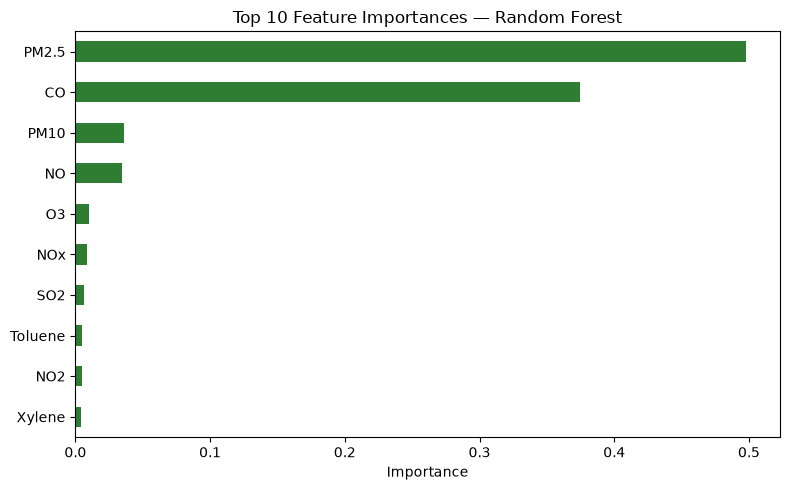

In [9]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
print(importances)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind="barh", color="#2E7D32")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [10]:
import joblib

joblib.dump(rf, "../dashboard/model.pkl")
joblib.dump(feature_cols, "../dashboard/model_features.pkl")

print("Saved model.pkl and model_features.pkl to /dashboard")

Saved model.pkl and model_features.pkl to /dashboard
